In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/synthetic_student_week_data.csv")

# Basic checks
assert {"student_id","week","post_period","treatment"}.issubset(df.columns)
df["treatment"] = df["treatment"].astype(bool)
df["post_period"] = df["post_period"].astype(bool)

# Student-level baseline table
stu = (df.sort_values(["student_id","week"])
         .groupby("student_id", as_index=False)
         .first()[["student_id","treatment","grade_level","ses_band","baseline_score","baseline_engagement"]])

display(df.head())
print("Rows:", len(df), " Students:", df["student_id"].nunique())

,student_id,grade_level,ses_band,baseline_score,baseline_engagement,treatment,week,post_period,weekly_active_days,assignments_completed,engagement_index,assessment_score
0,1,6,mid,72.786471,3.15067,False,1,False,3,2,2.5,69.946917
1,1,6,mid,72.786471,3.15067,False,3,False,2,2,2.0,71.182093
2,1,6,mid,72.786471,3.15067,False,4,False,4,5,4.5,70.695706
3,1,6,mid,72.786471,3.15067,False,5,False,4,1,2.5,72.494023
4,1,6,mid,72.786471,3.15067,False,6,False,3,2,2.5,72.593499


Rows: 90761  Students: 8000


In [2]:
# Numeric balance
balance_numeric = (stu.groupby("treatment")[["baseline_score","baseline_engagement"]]
                     .agg(["mean","std","count"])
                     .round(3))

# Categorical balance (shares)
ses_mix = (pd.crosstab(stu["ses_band"], stu["treatment"], normalize="columns")
             .rename(columns={False:"control_share", True:"treat_share"})
             .round(3))

grade_mix = (pd.crosstab(stu["grade_level"], stu["treatment"], normalize="columns")
               .rename(columns={False:"control_share", True:"treat_share"})
               .round(3))

print("Numeric balance:")
display(balance_numeric)
print("SES mix:")
display(ses_mix)
print("Grade mix:")
display(grade_mix)

Numeric balance:


baseline_score               baseline_engagement             
                    mean     std count                mean    std count
treatment                                                              
False             70.212   9.824  4005               3.527  1.039  4005
True              70.220  10.109  3995               3.509  1.044  3995

SES mix:


treatment,control_share,treat_share
ses_band,,
high,0.241,0.241
low,0.303,0.303
mid,0.456,0.457


Grade mix:


treatment,control_share,treat_share
grade_level,,
6,0.145,0.145
7,0.147,0.146
8,0.142,0.142
9,0.151,0.151
10,0.133,0.133
11,0.146,0.146
12,0.137,0.137


In [3]:
pre = df[~df["post_period"]].copy()

pre_means = (pre.groupby("treatment")[["weekly_active_days","assignments_completed","engagement_index","assessment_score"]]
               .mean()
               .rename(index={False:"control_pre", True:"treat_pre"})
               .round(3))

pre_diff = (pre.groupby("treatment")[["weekly_active_days","assignments_completed","engagement_index","assessment_score"]]
              .mean()
              .pipe(lambda x: x.loc[True] - x.loc[False])
              .to_frame("treat_minus_control_pre")
              .round(3))

display(pre_means)
display(pre_diff)

,weekly_active_days,assignments_completed,engagement_index,assessment_score
treatment,,,,
control_pre,3.315,2.382,2.848,70.664
treat_pre,3.296,2.365,2.830,70.670


,treat_minus_control_pre
weekly_active_days,-0.019
assignments_completed,-0.017
engagement_index,-0.018
assessment_score,0.006


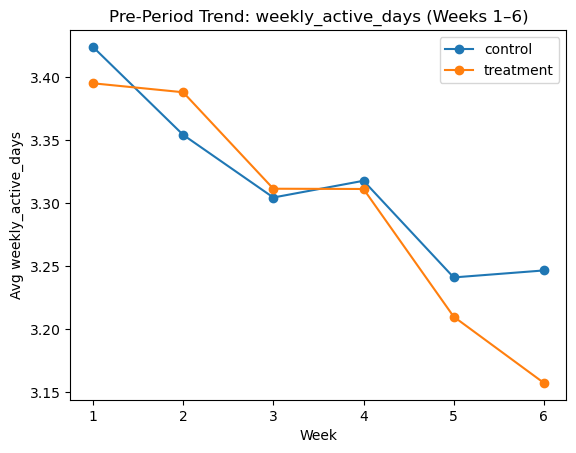

In [4]:
metric = "weekly_active_days" 

trend_pre = (pre.groupby(["week","treatment"], as_index=False)[metric]
               .mean()
               .sort_values(["week","treatment"]))

for key, g in trend_pre.groupby("treatment"):
    label = "treatment" if key else "control"
    plt.plot(g["week"], g[metric], marker="o", label=label)

plt.title(f"Pre-Period Trend: {metric} (Weeks 1–6)")
plt.xlabel("Week")
plt.ylabel(f"Avg {metric}")
plt.legend()
plt.show()

In [5]:
import statsmodels.formula.api as smf

pre2 = pre.copy()
pre2["week_c"] = pre2["week"] - pre2["week"].min()  # center for interpretability

# pre-trend test: outcome ~ treatment + week + treatment*week
model = smf.ols("weekly_active_days ~ treatment + week_c + treatment:week_c", data=pre2).fit(cov_type="HC3")
print(model.summary().tables[1])

                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    3.4015      0.023    149.242      0.000       3.357       3.446
treatment[T.True]            0.0173      0.032      0.536      0.592      -0.046       0.080
week_c                      -0.0347      0.008     -4.615      0.000      -0.049      -0.020
treatment[T.True]:week_c    -0.0146      0.011     -1.375      0.169      -0.035       0.006


In [6]:
pre3 = pre.copy()
pre3["placebo_post"] = pre3["week"] >= 4  # fake intervention at week 4
pre3["treat_x_placebo"] = pre3["treatment"].astype(int) * pre3["placebo_post"].astype(int)

placebo = smf.ols("weekly_active_days ~ treatment + placebo_post + treat_x_placebo", data=pre3).fit(cov_type="HC3")
print(placebo.summary().tables[1])

                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                3.3611      0.018    184.323      0.000       3.325       3.397
treatment[T.True]        0.0038      0.026      0.148      0.883      -0.047       0.054
placebo_post[T.True]    -0.0926      0.026     -3.598      0.000      -0.143      -0.042
treat_x_placebo         -0.0462      0.036     -1.268      0.205      -0.118       0.025


## Experimental Validation Summary

Baseline characteristics (grade level, socioeconomic band, baseline assessment score, and baseline engagement) are well balanced between treatment and control groups, consistent with successful stratified randomization.

Pre-intervention outcomes are closely aligned across groups, and visual inspection of pre-period trends shows similar trajectories prior to the intervention. A formal pre-trend regression finds no statistically meaningful difference in pre-intervention slopes between treatment and control groups.

A placebo test assigning a fictitious intervention during the pre-period yields no treatment-specific effect, providing additional support for the validity of the experimental design and the plausibility of the parallel trends assumption.